<a href="https://colab.research.google.com/github/Torranci/Project-CNN/blob/Torranci-AI-Security-Project/Project_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project CNN

In [68]:
import torch                          # Imports the main PyTorch library which provides the primary functions for building and training neural networks.
import torch.nn as nn                 # Imports the `torch.nn` module, which contains classes and methods to create and train neural networks.
import torch.optim as optim           # controls how the model learns
import torchvision                    # Importing Torchvision gives me easy access to the MNIST dataset
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#Making the Model Learn
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.00005,)

# this just helps speed things up if a GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [69]:
print("Device:", device)
# MNIST is 28x28 grayscale handwritten digits

# converting images into tensors so the model can read them
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize((0.5,), (0.5,))  # Normalize images to [-1, 1]
])

Device: cpu


In [63]:
#Model Implentation
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # first convolution layer
        # takes 1 channel (grayscale) → outputs 32 feature maps
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        # second convolution layer
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # max pooling cuts the image size in half
        self.pool = nn.MaxPool2d(2, 2)
        # dropout to help prevent overfitting
        self.dropout = nn.Dropout(0.25)
        # fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 digits (0-9)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))        # first conv layer → ReLU → pooling
        x = self.pool(torch.relu(self.conv2(x)))        # second conv layer
        x = x.view(-1, 64 * 7 * 7)    # flatten the data so it can go into the fully connected layer
        x = torch.relu(self.fc1(x))   # fully connected layer with ReLU
        x = self.dropout(x)           # dropout here to reduce overfitting
        x = self.fc2(x)               # final output layer

        return x


# create the model and send it to device
model = CNN().to(device)

In [70]:
# training data (60k images)
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# testing data (10k images)
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [71]:
# DataLoader helps break the dataset into batches
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

if train_loader is not None and test_loader is not None: # Corrected syntax
    print("The train_loader and test_loader now contain the MNIST dataset, ready for use in training and evaluation of a machine learning model.")

The train_loader and test_loader now contain the MNIST dataset, ready for use in training and evaluation of a machine learning model.


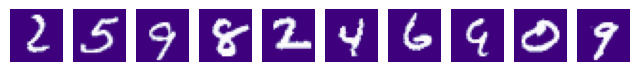

In [72]:
def show_images(images):
    plt.figure(figsize=(8,2))
    for i in range(10):
        plt.subplot(1,10,i+1)
        plt.imshow(images[i].squeeze(), cmap='Purples_r')
        plt.axis('off')
    plt.show()

# just grabbing a batch to see what the digits look like
dataiter = iter(train_loader)
images, labels = next(dataiter)
show_images(images)

In [73]:
#Training
num_epochs = 5

train_losses = []
train_accuracies = []

model.train()

for epoch in range(num_epochs):

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # forward pass
        outputs = model(images)

        # calculate loss
        loss = criterion(outputs, labels)

        # backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # checking accuracy while training
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    # average loss + accuracy for the epoch
    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total

    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {accuracy:.4f}")

Epoch 1: Loss = 0.7191, Accuracy = 0.8172
Epoch 2: Loss = 0.2176, Accuracy = 0.9367
Epoch 3: Loss = 0.1432, Accuracy = 0.9577
Epoch 4: Loss = 0.1086, Accuracy = 0.9682
Epoch 5: Loss = 0.0880, Accuracy = 0.9742


In [74]:
# Evaluation
model.eval()  # set model to evaluation mode
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f'Accuracy: {accuracy:.4f} %')

Accuracy: 0.9826 %


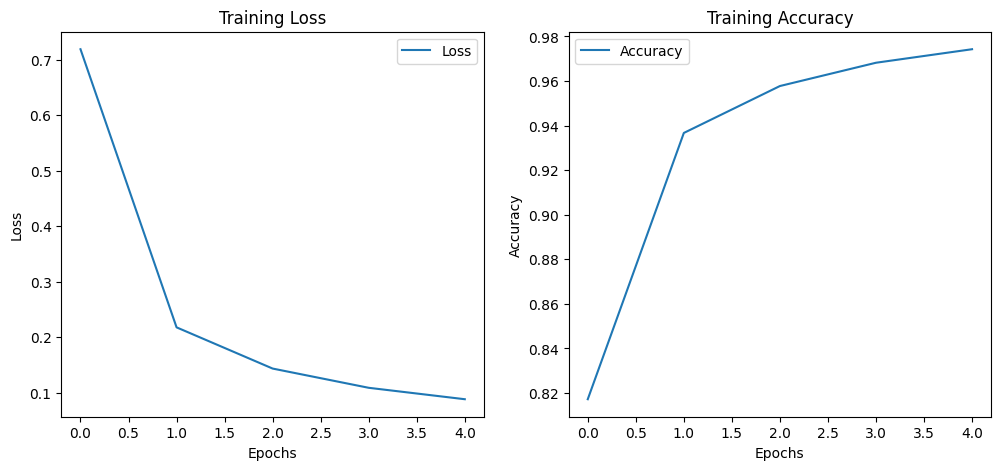

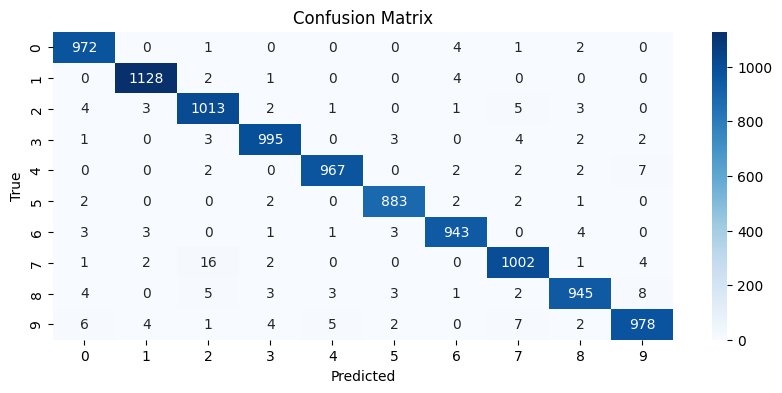

In [75]:
# Plot training loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()


# Plot training Accuracy
plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.show()

#Confusion matrix
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

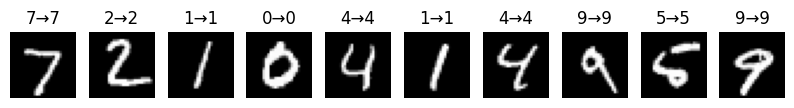

In [76]:
#Predictions
def show_predictions(images, labels, preds):
    plt.figure(figsize=(10,2))
    for i in range(10):
        plt.subplot(1,10,i+1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        plt.title(f"{labels[i].item()}→{preds[i].item()}")
        plt.axis('off')
    plt.show()

# grab a batch from test set
dataiter = iter(test_loader)
images, labels = next(dataiter)

images = images.to(device)
labels = labels.to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

show_predictions(images[:10], labels[:10], predicted[:10])